In [18]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import graphviz

In [19]:
# Loading dataset
df = pd.read_csv("heart.csv")

In [20]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [22]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [23]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [24]:
# Drop duplicates if any
df = df.drop_duplicates()

In [25]:
# Selecting features and target
X = df.drop("target", axis=1)
y = df["target"]

In [26]:
# Optional: Standardize features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [28]:
# Decision Tree Classifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

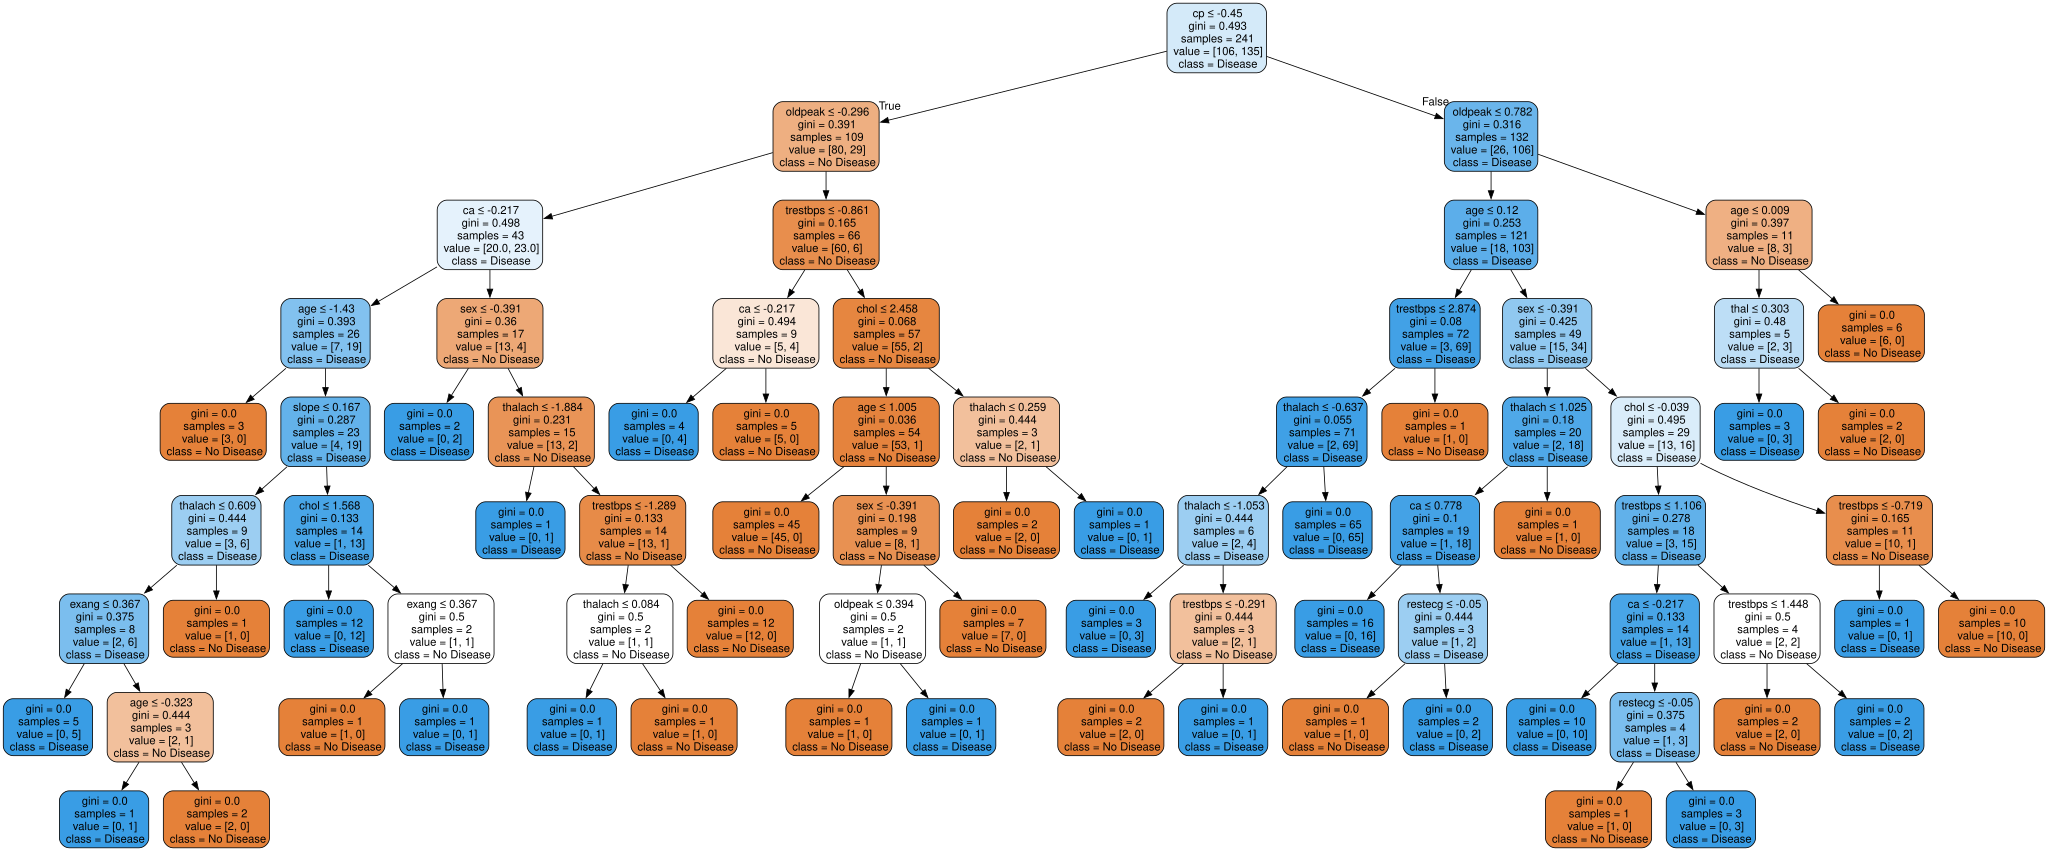

In [31]:
# Visualize the Decision Tree
data_g = export_graphviz(tree_model, out_file=None, 
                           feature_names=X.columns,  
                           class_names=['No Disease', 'Disease'],  
                           filled=True, rounded=True,  
                           special_characters=True)  
graph = graphviz.Source(data_g)  
graph.render("decision_tree_heart")  # Save the tree as a PDF
graph


In [36]:
# Pruned Decision Tree (max_depth=3)
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train, y_train)

y_pred_pruned = pruned_tree.predict(X_test)
print("Pruned Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))
print(classification_report(y_test, y_pred_pruned))

Pruned Tree Accuracy: 0.7540983606557377
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        32
           1       0.72      0.79      0.75        29

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61



In [37]:
# Visualize pruned tree
dot_data_pruned = export_graphviz(pruned_tree,
                                  out_file=None,
                                  feature_names=X.columns,
                                  class_names=["No Disease", "Disease"],
                                  filled=True, rounded=True, special_characters=True)
graph_pruned = graphviz.Source(dot_data_pruned)
graph_pruned.render("pruned_decision_tree")
graph_pruned.view()

'pruned_decision_tree.pdf'

In [38]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8360655737704918
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



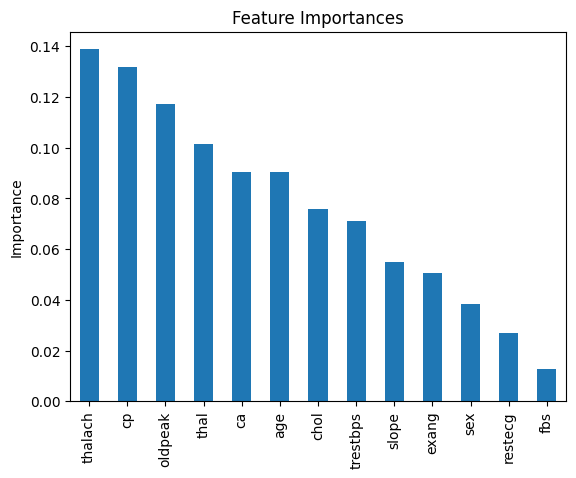

In [39]:
#Feature importance
importances = rf_model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_importance.plot(kind='bar', title='Feature Importances')
plt.ylabel('Importance')
plt.show()

In [40]:
# Cross-validation
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5)
print("Random Forest CV Accuracy:", cv_scores.mean())

Random Forest CV Accuracy: 0.8278142076502732


In [41]:
import seaborn as sn

In [42]:
# Accuracy values (replace pruned_acc with your actual printed value if different)
pruned_acc = accuracy_score(y_test, y_pred_pruned)
rf_acc = accuracy_score(y_test, y_pred_rf)

In [43]:
# Prepare data
model_names = ['Pruned Decision Tree', 'Random Forest']
accuracies = [pruned_acc, rf_acc]

C:\Users\maris\AppData\Local\Temp\ipykernel_12700\2708401727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(x=model_names, y=accuracies, palette='viridis')


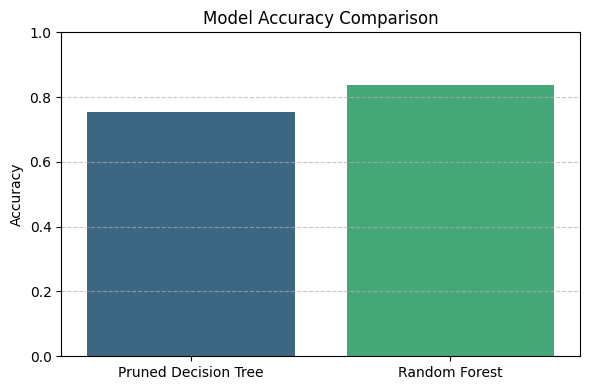

In [45]:
# Plot
plt.figure(figsize=(6, 4))
sn.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
# Get accuracy scores
dt_acc = accuracy_score(y_test, tree_model.predict(X_test))         # Full decision tree
pruned_acc = accuracy_score(y_test, y_pred_pruned)                 # Pruned tree
rf_acc = accuracy_score(y_test, y_pred_rf)                         # Random forest

In [47]:
# Prepare data for bar plot
model_names = ['Decision Tree', 'Pruned Decision Tree', 'Random Forest']
accuracies = [dt_acc, pruned_acc, rf_acc]

C:\Users\maris\AppData\Local\Temp\ipykernel_12700\2845285525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(x=model_names, y=accuracies, palette='Set2')


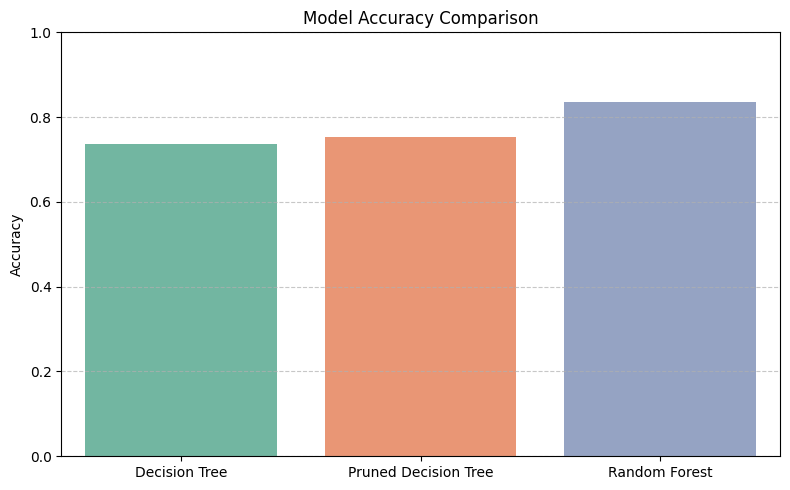

In [49]:
plt.figure(figsize=(8, 5))
sn.barplot(x=model_names, y=accuracies, palette='Set2')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()